# 01_EDA: 基本検証ノートブック

このノートブックでは、データの基本的な性質を確認し、モデル設計の前提を検証します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import sys
import os

# src読み込み用パス設定
sys.path.append('..')
from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 1. データ読み込みとパイプライン実行

In [2]:
excel_path = '../data/BOJ_data.xlsx'
meeting_path = '../data/BOJ_meeting_history.csv'

df_clean = load_and_clean_data(excel_path, meeting_path)
df_feat = generate_features(df_clean)
df_pooled = pool_boj_data(df_feat)

print(f"Raw Cleaned Shape: {df_clean.shape}")
print(f"Featured Shape: {df_feat.shape}")
print(f"Pooled Shape: {df_pooled.shape}")
df_pooled.head()

Raw Cleaned Shape: (732, 23)
Featured Shape: (732, 43)
Pooled Shape: (5856, 35)


,Date,Meeting_Index,is_post_mpm,Days_to_MPM,Actual_Policy_Rate,M1_spread,M2_spread,M3_spread,M4_spread,M5_spread,...,M5_is_imputed,M6_is_imputed,M7_is_imputed,M8_is_imputed,USDJPY_frac_diff,JGB_Future_frac_diff,Nikkei225_frac_diff,Target_1d,Target_3d,Target_5d
0,2023-02-24,1,0,14.0,-0.1,0.09375,0.11250,0.14375,0.1800,0.21375,...,0,0,1,1,NaN,NaN,NaN,0.00000,-0.00125,-0.00125
1,2023-02-27,1,0,11.0,-0.1,0.09375,0.11500,0.13875,0.1775,0.22250,...,0,0,1,1,NaN,NaN,NaN,0.00000,-0.00125,-0.00125
2,2023-02-28,1,0,10.0,-0.1,0.09375,0.11625,0.14125,0.1750,0.21125,...,0,0,1,1,NaN,NaN,NaN,-0.00125,-0.00125,-0.00250
3,2023-03-01,1,0,9.0,-0.1,0.09250,0.11375,0.14625,0.1725,0.20250,...,0,0,1,1,NaN,NaN,NaN,0.00000,0.00000,-0.00125
4,2023-03-02,1,0,8.0,-0.1,0.09250,0.11500,0.14125,0.1750,0.20875,...,0,0,1,1,NaN,NaN,NaN,0.00000,-0.00125,0.00125


## 2. M{n}スプレッドの時系列プロット

MPM日付（縦線）との関係を確認します。

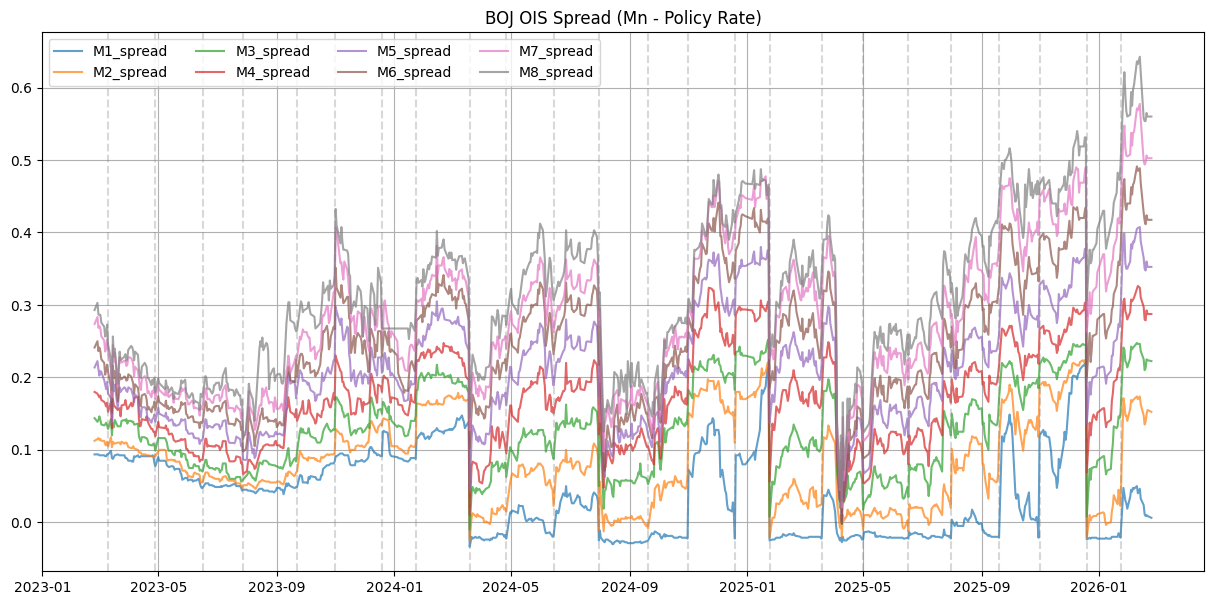

In [3]:
plt.figure(figsize=(15, 7))
for i in range(1, 9):
    col = f'M{i}_spread'
    plt.plot(df_feat['Date'], df_feat[col], label=col, alpha=0.7)

meeting_dates = df_feat[df_feat['Is_Meeting_Day'] == 1]['Date']
for d in meeting_dates:
    plt.axvline(d, color='gray', linestyle='--', alpha=0.3)

plt.title("BOJ OIS Spread (Mn - Policy Rate)")
plt.legend(ncol=4)
plt.grid(True)
plt.show()

## 3. 分数階差の確認と定常性検証

M1_spread と M1_frac_diff を比較し、ADF検定を行います。

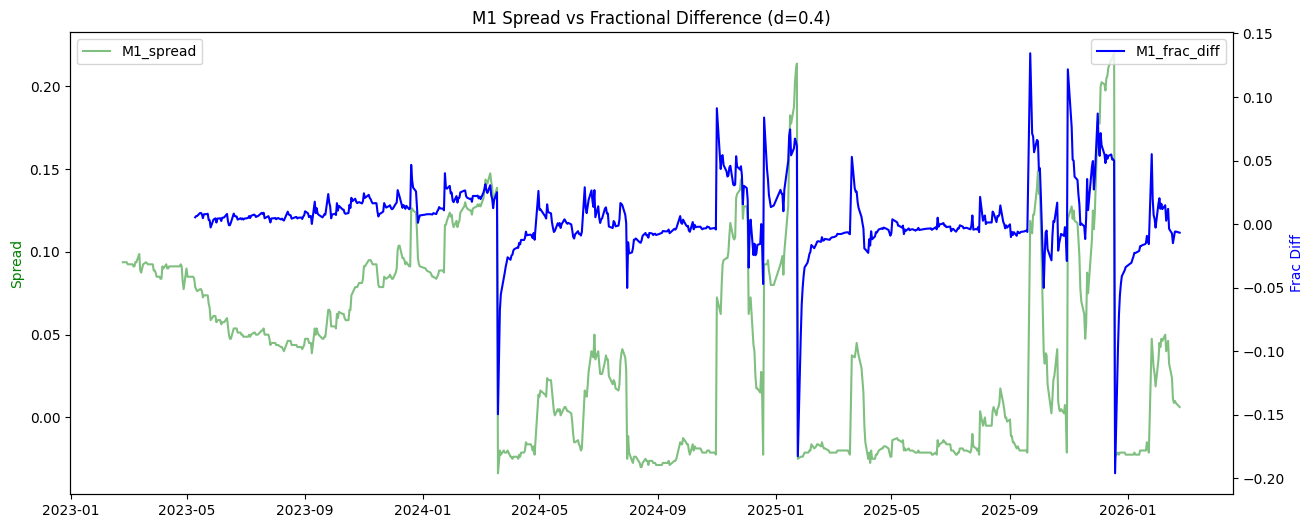

--- ADF Test Results (p-values) ---
M1_frac_diff: 0.0000
M2_frac_diff: 0.0000
M3_frac_diff: 0.0000
M4_frac_diff: 0.0000
M5_frac_diff: 0.0000


M6_frac_diff: 0.0000
M7_frac_diff: 0.0000
M8_frac_diff: 0.0000


In [4]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()
ax1.plot(df_feat['Date'], df_feat['M1_spread'], 'g-', label='M1_spread', alpha=0.5)
ax2.plot(df_feat['Date'], df_feat['M1_frac_diff'], 'b-', label='M1_frac_diff')

ax1.set_ylabel('Spread', color='g')
ax2.set_ylabel('Frac Diff', color='b')
plt.title("M1 Spread vs Fractional Difference (d=0.4)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

print("--- ADF Test Results (p-values) ---")
for i in range(1, 9):
    col = f'M{i}_frac_diff'
    series = df_feat[col].dropna()
    if len(series) > 0:
        p_val = adfuller(series)[1]
        print(f"{col}: {p_val:.4f}")

## 4. 目的変数の分布と統計量

is_post_mpm 除外後の統計量を確認します。

有効サンプル数 (is_post_mpm 除外後): 4704

--- Target Statistics ---


,Target_1d,Target_3d,Target_5d
count,4696.000000,4680.000000,4664.000000
mean,0.000248,0.003343,0.006142
std,0.015633,0.028923,0.036511
min,-0.153623,-0.314804,-0.332789
25%,-0.005000,-0.008750,-0.010000
50%,0.000000,0.000605,0.002500
75%,0.005000,0.013750,0.021250
max,0.141250,0.148750,0.145000


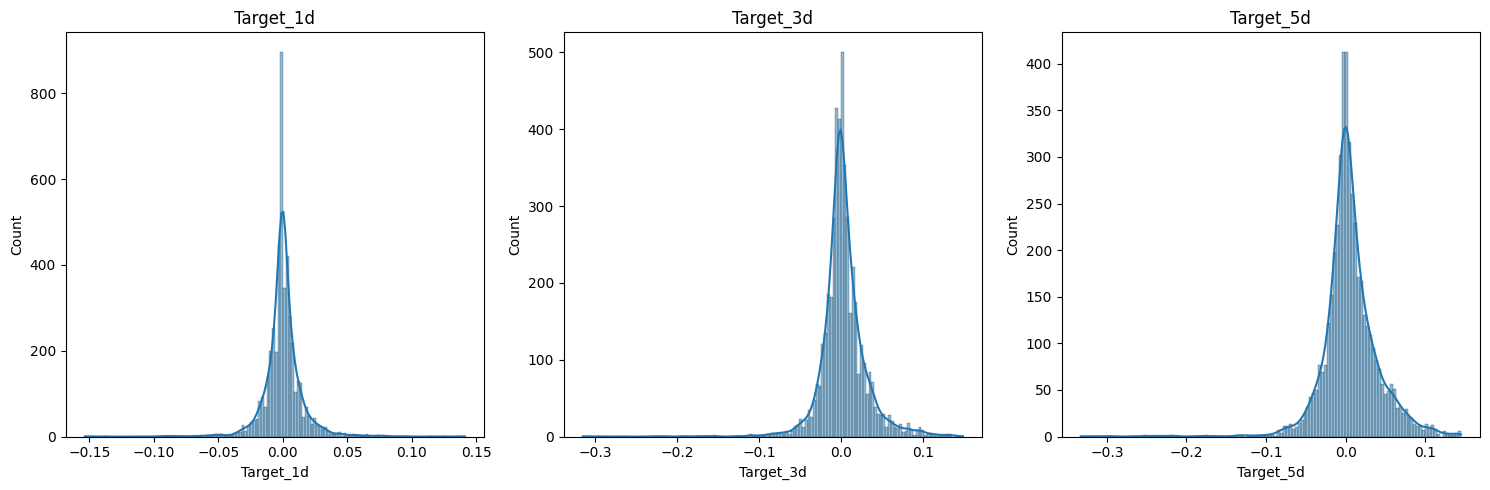

In [5]:
df_valid = df_pooled[df_pooled['is_post_mpm'] == 0].copy()
target_cols = ['Target_1d', 'Target_3d', 'Target_5d']

print(f"有効サンプル数 (is_post_mpm 除外後): {len(df_valid)}")
print("\n--- Target Statistics ---")
display(df_valid[target_cols].describe())

plt.figure(figsize=(15, 5))
for i, col in enumerate(target_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_valid[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

## 5. 欠損・補完状況の確認

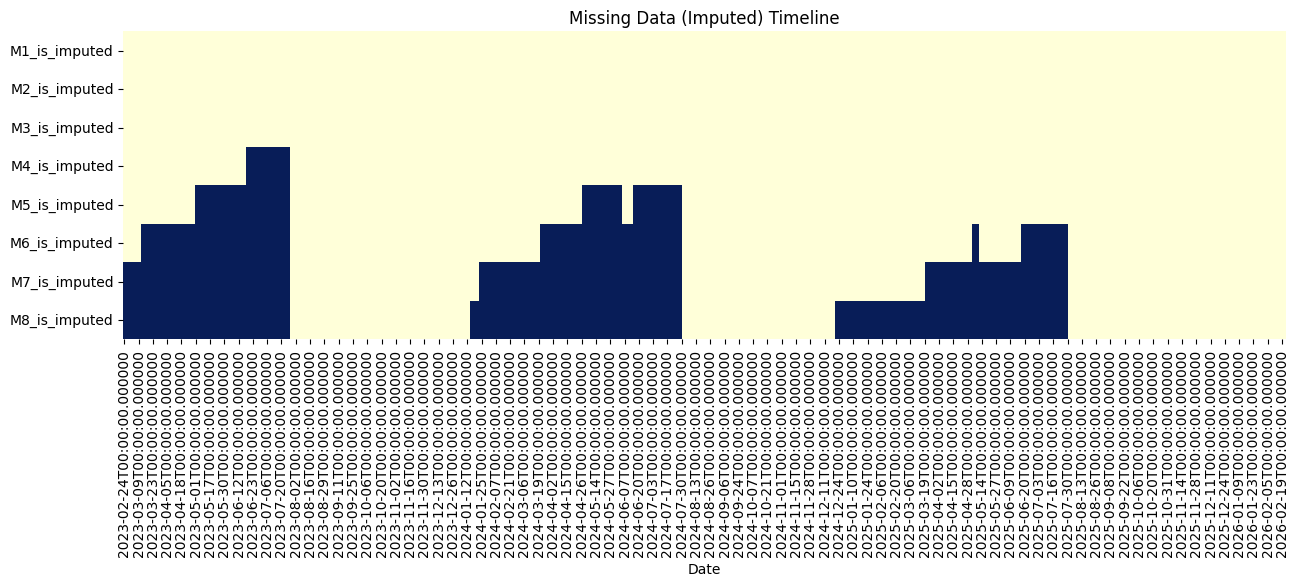

In [6]:
impute_cols = [f'M{i}_is_imputed' for i in range(1, 9)]
plt.figure(figsize=(15, 4))
sns.heatmap(df_feat.set_index('Date')[impute_cols].T, cmap='YlGnBu', cbar=False)
plt.title("Missing Data (Imputed) Timeline")
plt.show()